In [1]:
import pandas as pd
import numpy as np
import ta
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv( "C:/Users/DELL/Desktop/UOIT/capstone/AMZN_alpha_1min_2024-05_to_2025-05.csv")

 #Convert 'Timestamp' from object to datetime.
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

#check if it is  converted
print( "the data type of 'Timestap' in dataset is", df['Timestamp'].dtype)

the data type of 'Timestap' in dataset is datetime64[ns]


In [3]:
# Define regular trading hours

market_open = datetime.time(9, 30)
market_close = datetime.time(16, 0)

# Keep only rows within regular trading hours
df = df[
    (df['Timestamp'].dt.time >= market_open) & 
    (df['Timestamp'].dt.time <= market_close)
].copy()

print(f" First {df.head(1)}")
print(f" Last {df.tail(1)}")

 First               Timestamp     Open   High     Low   Close   Volume
330 2024-05-01 09:30:00  181.635  182.0  180.29  181.36  1786342
 Last                  Timestamp    Open    High    Low  Close    Volume
236504 2025-04-30 16:00:00  184.32  187.25  183.7  185.6  20316526


In [7]:
print(df.columns)


Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [8]:
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#

In [9]:
# RCI_9
def rci(series, period=9):
    result = np.full(len(series), np.nan)
    for i in range(period-1, len(series)):
        price = series[i-period+1:i+1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1  # rank
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff**2)) / (period * (period**2 - 1))) * 100
        result[i] = rci_value
    return result

#  RCI (9 periods)
df['RCI_9'] = rci(df['Close'], period=14)

# CCI
df['CCI'] = ta.trend.cci(df['High'], df['Low'], df['Close'], window=20, fillna=True)


# 3. MACD
macd = ta.trend.macd(df['Close'], window_slow=26, window_fast=12)
macd_signal = ta.trend.macd_signal(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd
df['MACD_signal'] = macd_signal
df['MACD_hist'] = macd - macd_signal

# 4. KAMA
df['KAMA'] = ta.momentum.kama(df['Close'], window=10, pow1=2, pow2=30, fillna=True)

# 5. ROC
df['ROC'] = ta.momentum.roc(df['Close'], window=14, fillna=True)
# https://www.avatrade.ca/education/technical-analysis-indicators-strategies/roc-indicator-strategies#2

# 6. EMA12
df['EMA12'] = ta.trend.ema_indicator(df['Close'], window=12, fillna=True)
# https://www.thinkmarkets.com/en/trading-academy/forex/exponential-moving-averages/

# 7. Relative Strength Index (RSI)
df['RSI'] = ta.momentum.rsi(df['Close'], window=7, fillna=True)
# https://choiceindia.com/blog/best-rsi-setting-for-intraday

# 8. Money Flow Index (MFI)
df['MFI'] = ta.volume.money_flow_index(df['High'], df['Low'], df['Close'], df['Volume'], window=14, fillna=True)

# 9. Relative Vigor Index (RVI) -- not directly available, define custom
def rvi_strict(close, open_, high, low, window=10):
    # Calculate 4-bar weighted sum for numerator (Close-Open)
    a = close - open_
    b = close.shift(1) - open_.shift(1)
    c = close.shift(2) - open_.shift(2)
    d = close.shift(3) - open_.shift(3)
    numerator = (a + 2*b + 2*c + d) / 6

    # Calculate 4-bar weighted sum for denominator (High-Low)
    e = high - low
    f = high.shift(1) - low.shift(1)
    g = high.shift(2) - low.shift(2)
    h = high.shift(3) - low.shift(3)
    denominator = (e + 2*f + 2*g + h) / 6

    # Rolling mean for N periods
    num_sma = numerator.rolling(window=window).mean()
    denom_sma = denominator.rolling(window=window).mean()

    # RVI calculation
    rvi = num_sma / denom_sma
    return rvi


df['RVI'] = rvi_strict(df['Close'], df['Open'], df['High'], df['Low'], window=10)

# https://www.investopedia.com/terms/r/relative_vigor_index.asp
# https://www.avatrade.ca/education/technical-analysis-indicators-strategies/rvi-indicator-strategies

# 10. Williams %R
df['WilliamsR'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'], lbp=14, fillna=True)
# https://trendspider.com/learning-center/introduction-to-williams-r-range/

# 11. Percentage Price Oscillator (PPO)
df['PPO'] = ta.momentum.ppo(df['Close'], window_slow=26, window_fast=12, window_sign=9, fillna=True)
# https://www.investopedia.com/terms/p/ppo.asp

# 12. Pivot Point (Classic) -- daily
df['Pivot_Point'] = (df['High'] + df['Low'] + df['Close']) / 3

# 13. Stochastic Oscillator
# Calculate %K
df['Stoch_K'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'], window=14, smooth_window=3, fillna=True)
# Calculate %D (the signal line) as SMA of %K
df['Stoch_D'] = df['Stoch_K'].rolling(window=3).mean()
# https://www.investopedia.com/terms/s/stochasticoscillator.asp

# 14. Internal Bar Strength (IBS)
df['IBS'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

# 15. Chaikin Money Flow (CMF)
def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

df['CMF'] = chaikin_money_flow(df, window=20)
# https://help.stockdoctor.com.au/hc/en-us/articles/360000099635-Chaikin-Money-Flow

In [10]:
print(df.columns)
print("Number of columns:", len(df.columns))

Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'RCI_9', 'CCI',
       'MACD', 'MACD_signal', 'MACD_hist', 'KAMA', 'ROC', 'EMA12', 'RSI',
       'MFI', 'RVI', 'WilliamsR', 'PPO', 'Pivot_Point', 'Stoch_K', 'Stoch_D',
       'IBS', 'CMF'],
      dtype='object')
Number of columns: 24


In [11]:
# drop NaN from both datasets
df = df.dropna().reset_index(drop=True)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

#Checking if duplicated rows exist.
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)


Missing Values:
Timestamp      0
Open           0
High           0
Low            0
Close          0
Volume         0
RCI_9          0
CCI            0
MACD           0
MACD_signal    0
MACD_hist      0
KAMA           0
ROC            0
EMA12          0
RSI            0
MFI            0
RVI            0
WilliamsR      0
PPO            0
Pivot_Point    0
Stoch_K        0
Stoch_D        0
IBS            0
CMF            0
dtype: int64
number of duplicate rows:  (0, 24)


In [12]:
#--------------------------Evaluation------------------------#

RCI
Number of trades: 1250
Sum of return: 0.3154
Cumulative return: 32.6708%
Average return per trade: 0.0002523

Sample trades:
Trade 1: Entry at 21, Exit at 46, Each Return: 0.0738%
Trade 2: Entry at 93, Exit at 110, Each Return: -0.2579%
Trade 3: Entry at 136, Exit at 211, Each Return: 0.3833%
Trade 4: Entry at 230, Exit at 334, Each Return: 2.2400%
Trade 5: Entry at 368, Exit at 398, Each Return: -0.2677%
Trade 6: Entry at 420, Exit at 434, Each Return: -0.2202%
Trade 7: Entry at 445, Exit at 470, Each Return: 0.1869%
Trade 8: Entry at 497, Exit at 525, Each Return: 0.0248%
Trade 9: Entry at 537, Exit at 570, Each Return: 0.1043%
Trade 10: Entry at 579, Exit at 628, Each Return: 0.9970%
Average return per trade: 0.000252


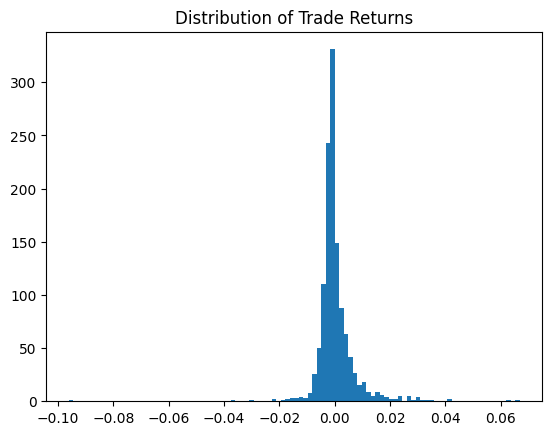

In [32]:
# RCI_9 standard threshold

rci_buy_std = -80   # Example buy threshold for RCI
rci_sell_std = 80   # Example sell threshold for RCI

holding_position = False      # Not in a trade to start
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    rci = df['RCI_9'].iloc[i]
    
    # ENTRY: Only if not already holding a position
    if not holding_position and rci < rci_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):  # Out-of-bounds check
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and rci > rci_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):  # Out-of-bounds check
            break
        
        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")
        
        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        
        holding_position = False


# 
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0


print("RCI")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4}")

print("\nSample trades:")
for i in range(min(10, len(each_return))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")

print(f"Average return per trade: {np.mean(each_return):.6f}")
import matplotlib.pyplot as plt
plt.hist(each_return, bins=100)
plt.title("Distribution of Trade Returns")
plt.show()


RCI
Number of trades: 1250
Sum of return: 0.3154
Cumulative return: 32.6708%
Average return per trade: 0.0002523
Average return per day (while in trade): 0.0000061946
Win rate: 36.64%
Max drawdown: -18.92%

Sample trades:
Trade 1: Entry at 21, Exit at 46, Days held: 25, Each Return: 0.0738%
Trade 2: Entry at 93, Exit at 110, Days held: 17, Each Return: -0.2579%
Trade 3: Entry at 136, Exit at 211, Days held: 75, Each Return: 0.3833%
Trade 4: Entry at 230, Exit at 334, Days held: 104, Each Return: 2.2400%
Trade 5: Entry at 368, Exit at 398, Days held: 30, Each Return: -0.2677%
Trade 6: Entry at 420, Exit at 434, Days held: 14, Each Return: -0.2202%
Trade 7: Entry at 445, Exit at 470, Days held: 25, Each Return: 0.1869%
Trade 8: Entry at 497, Exit at 525, Days held: 28, Each Return: 0.0248%
Trade 9: Entry at 537, Exit at 570, Days held: 33, Each Return: 0.1043%
Trade 10: Entry at 579, Exit at 628, Days held: 49, Each Return: 0.9970%


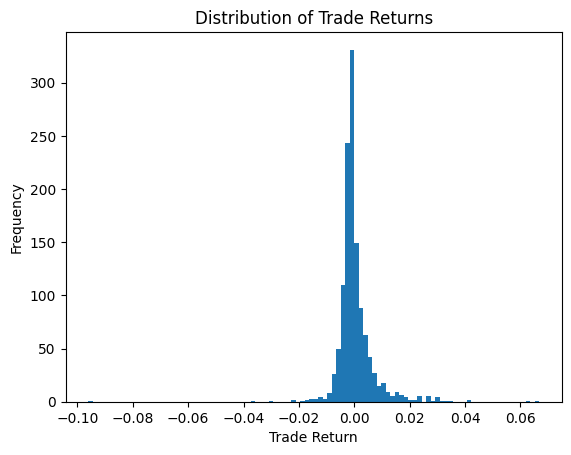

In [41]:
# RCI max drawdown

rci_buy_std = -80   # Example buy threshold for RCI
rci_sell_std = 80   # Example sell threshold for RCI

holding_position = False      # Not in a trade to start
entry_index = None

buy_indices = []
sell_indices = []
each_return = []
trade_days = []  # Store number of days held per trade

# --- Main trading loop ---
for i in range(len(df) - 1):
    rci = df['RCI_9'].iloc[i]
    
    # ENTRY: Only if not already holding a position
    if not holding_position and rci < rci_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):  # Out-of-bounds check
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and rci > rci_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):  # Out-of-bounds check
            break
        
        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")
        
        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        
        # Add holding period in days
        trade_days.append(exit_index - entry_index)
        
        holding_position = False

# --- Performance metrics ---
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

# ---- Win rate ----
num_wins = sum(r > 0 for r in each_return)
winrate = num_wins / len(each_return) if each_return else 0

# ---- Max drawdown ----
if each_return:
    equity_curve = np.cumprod([1 + r for r in each_return])
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()
else:
    max_drawdown = 0

# ---- Average return per day (only for held trade days) ----
total_days = sum(trade_days) if trade_days else 0
average_return_per_day = (sum(each_return) / total_days) if total_days > 0 else 0

print("RCI")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4}")
print(f"Average return per day (while in trade): {average_return_per_day:.10f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max drawdown: {max_drawdown:.2%}")

print("\nSample trades:")
for i in range(min(10, len(each_return))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, "
          f"Days held: {trade_days[i]}, Each Return: {each_return[i]:.4%}")

plt.hist(each_return, bins=100)
plt.title("Distribution of Trade Returns")
plt.xlabel("Trade Return")
plt.ylabel("Frequency")
plt.show()


In [28]:
# CCI standard threshold

cci_buy_std = -100   # Common buy threshold for CCI
cci_sell_std = 100   # Common sell threshold for CCI

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
returns = []

for i in range(len(df) - 1):
    cci = df['CCI'].iloc[i]

    # ENTRY: Only if not already holding a position
    if not holding_position and cci < cci_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and cci > cci_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug: check for same-bar trade
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        returns.append(trade_return)

        holding_position = False


sum_return = sum(returns)
cumulative_return = (np.prod([1 + r for r in returns]) - 1) if returns else 0

print("CCI")
print(f"Number of trades: {len(returns)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}\n")
average_return = sum(returns) / len(returns) if each_return else 0
print(f"Average return per trade: {average_return:.4}")

print("Sample trades:")
for i in range(min(10, len(returns))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {returns[i]:.4%}")

print(f"\nAverage return per trade: {np.mean(returns):.6f}")



CCI
Number of trades: 1855
Sum of return: -0.1885
Cumulative return: -19.7765%

Average return per trade: -0.0001016
Sample trades:
Trade 1: Entry at 1, Exit at 32, Each Return: -0.2237%
Trade 2: Entry at 51, Exit at 89, Each Return: -1.0221%
Trade 3: Entry at 109, Exit at 135, Each Return: -0.3034%
Trade 4: Entry at 152, Exit at 157, Each Return: 0.3361%
Trade 5: Entry at 179, Exit at 187, Each Return: 0.0815%
Trade 6: Entry at 192, Exit at 196, Each Return: 0.1423%
Trade 7: Entry at 213, Exit at 228, Each Return: 0.2839%
Trade 8: Entry at 329, Exit at 367, Each Return: -1.2157%
Trade 9: Entry at 391, Exit at 417, Each Return: 0.0165%
Trade 10: Entry at 433, Exit at 447, Each Return: 0.2856%

Average return per trade: -0.000102


In [15]:
# --- MACD Crossover Rule-Based Backtest (Go Long Only) ---

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
returns = []

for i in range(1, len(df) - 1):  # Start from 1 to use previous bar for crossover check
    macd_prev = df['MACD'].iloc[i-1] #previous macd 
    macd_sig_prev = df['MACD_signal'].iloc[i-1]
    macd = df['MACD'].iloc[i]
    macd_sig = df['MACD_signal'].iloc[i]
    
    # ENTRY: MACD crosses above MACD_signal (bullish crossover)
    # ENTRY: Bullish crossover AND both below zero
    if (
        not holding_position
        and (macd_prev <= macd_sig_prev) and (macd > macd_sig)
        and (macd < 0) and (macd_sig < 0)
    ):
        entry_index = i + 1
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: MACD crosses below MACD_signal (bearish crossover)
    elif holding_position and (macd_prev >= macd_sig_prev) and (macd < macd_sig):
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug: check for same-bar trade
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        returns.append(trade_return)

        holding_position = False


sum_return = sum(returns)
cumulative_return = (np.prod([1 + r for r in returns]) - 1) if returns else 0

print("MACD Crossover")
print(f"Number of trades: {len(returns)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}\n")
average_return = sum(each_return) / len(each_return) if each_return else 0
print(f"Average return per trade: {average_return:.4}")
average_return = sum(each_return) / len(each_return) if each_return else 0
print(f"Average return per trade: {average_return:.4}")

print("Sample trades:")
for i in range(min(10, len(returns))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {returns[i]:.4%}")

print(f"\nAverage return per trade: {np.mean(returns):.6f}")



MACD Crossover
Number of trades: 2409
Sum of return: -0.0683
Cumulative return: -8.7784%

Average return per trade: 0.0002523
Average return per trade: 0.0002523
Sample trades:
Trade 1: Entry at 16, Exit at 43, Each Return: 0.2222%
Trade 2: Entry at 79, Exit at 106, Each Return: 0.2471%
Trade 3: Entry at 128, Exit at 153, Each Return: 0.0848%
Trade 4: Entry at 154, Exit at 174, Each Return: 0.4062%
Trade 5: Entry at 225, Exit at 253, Each Return: 0.6292%
Trade 6: Entry at 359, Exit at 380, Each Return: 0.4251%
Trade 7: Entry at 413, Exit at 430, Each Return: -0.0055%
Trade 8: Entry at 489, Exit at 518, Each Return: 0.3747%
Trade 9: Entry at 534, Exit at 545, Each Return: -0.1455%
Trade 10: Entry at 658, Exit at 681, Each Return: 0.2938%

Average return per trade: -0.000028


In [16]:
# KAMA
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean() #use EMA200 as the reference

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
returns = []

for i in range(1, len(df) - 1):
    kama_prev = df['KAMA'].iloc[i-1]
    ema200_prev = df['EMA200'].iloc[i-1]
    kama = df['KAMA'].iloc[i]
    ema200 = df['EMA200'].iloc[i]
    
    # ENTRY: KAMA crosses above EMA200
    if (not holding_position) and (kama_prev <= ema200_prev) and (kama > ema200):
        entry_index = i + 1
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: KAMA crosses below EMA200
    elif holding_position and (kama_prev >= ema200_prev) and (kama < ema200):
        exit_index = i + 1
        if exit_index >= len(df):
            break

        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        returns.append(trade_return)

        holding_position = False

sum_return = sum(returns)
cumulative_return = (np.prod([1 + r for r in returns]) - 1) if returns else 0

print("MACD Crossover")
print(f"Number of trades: {len(returns)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}\n")
average_return = sum(each_return) / len(each_return) if each_return else 0
print(f"Average return per trade: {average_return:.4}")

print("Sample trades:")
for i in range(min(10, len(returns))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {returns[i]:.4%}")

print(f"\nAverage return per trade: {np.mean(returns):.6f}")


MACD Crossover
Number of trades: 439
Sum of return: -0.3179
Cumulative return: -29.3941%

Average return per trade: 0.0002523
Sample trades:
Trade 1: Entry at 202, Exit at 210, Each Return: -0.3859%
Trade 2: Entry at 233, Exit at 350, Each Return: 0.8097%
Trade 3: Entry at 371, Exit at 956, Each Return: 1.9171%
Trade 4: Entry at 965, Exit at 997, Each Return: -0.1020%
Trade 5: Entry at 1002, Exit at 1004, Each Return: -0.0951%
Trade 6: Entry at 1013, Exit at 1082, Each Return: -0.0912%
Trade 7: Entry at 1203, Exit at 1790, Each Return: 1.2604%
Trade 8: Entry at 1913, Exit at 1928, Each Return: -0.4588%
Trade 9: Entry at 1999, Exit at 2054, Each Return: -0.1862%
Trade 10: Entry at 2203, Exit at 2333, Each Return: 0.0187%

Average return per trade: -0.000724


In [17]:
# EMA12
holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
returns = []

for i in range(1, len(df) - 1):
    close_prev = df['Close'].iloc[i-1]
    ema12_prev = df['EMA12'].iloc[i-1]
    close = df['Close'].iloc[i]
    ema12 = df['EMA12'].iloc[i]
    
    # ENTRY: Close crosses above EMA12
    if (not holding_position) and (close_prev <= ema12_prev) and (close > ema12):
        entry_index = i + 1
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Close crosses below EMA12
    elif holding_position and (close_prev >= ema12_prev) and (close < ema12):
        exit_index = i + 1
        if exit_index >= len(df):
            break

        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        returns.append(trade_return)

        holding_position = False


sum_return = sum(returns)
cumulative_return = (np.prod([1 + r for r in returns]) - 1) if returns else 0

print("EMA12 Crossover")
print(f"Number of trades: {len(returns)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}\n")
average_return = sum(each_return) / len(each_return) if each_return else 0
print(f"Average return per trade: {average_return:.4}")

print("Sample trades:")
for i in range(min(10, len(returns))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {returns[i]:.4%}")

print(f"\nAverage return per trade: {np.mean(returns):.6f}")


EMA12 Crossover
Number of trades: 8585
Sum of return: -0.0630
Cumulative return: -8.7682%

Average return per trade: 0.0002523
Sample trades:
Trade 1: Entry at 15, Exit at 19, Each Return: -0.0111%
Trade 2: Entry at 20, Exit at 23, Each Return: -0.1111%
Trade 3: Entry at 25, Exit at 26, Each Return: -0.1776%
Trade 4: Entry at 27, Exit at 41, Each Return: 0.2611%
Trade 5: Entry at 79, Exit at 80, Each Return: -0.1404%
Trade 6: Entry at 85, Exit at 103, Each Return: 0.4062%
Trade 7: Entry at 104, Exit at 105, Each Return: -0.2126%
Trade 8: Entry at 130, Exit at 137, Each Return: -0.0222%
Trade 9: Entry at 139, Exit at 141, Each Return: -0.0345%
Trade 10: Entry at 143, Exit at 144, Each Return: -0.0510%

Average return per trade: -0.000007


In [18]:
#  ROC  

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
returns = []

for i in range(1, len(df) - 1):
    roc_prev = df['ROC'].iloc[i-1]
    roc = df['ROC'].iloc[i]

    # ENTRY: ROC crosses above 0
    if (not holding_position) and (roc_prev <= 0) and (roc > 0):
        entry_index = i + 1
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: ROC crosses below 0
    elif holding_position and (roc_prev >= 0) and (roc < 0):
        exit_index = i + 1
        if exit_index >= len(df):
            break

        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        returns.append(trade_return)

        holding_position = False

# --- Results Summary and Sample Trades ---
sum_return = sum(returns)
cumulative_return = (np.prod([1 + r for r in returns]) - 1) if returns else 0

print("ROC Zero Line Crossover")
print(f"Number of trades: {len(returns)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}\n")
average_return = sum(each_return) / len(each_return) if each_return else 0
print(f"Average return per trade: {average_return:.4}")

print("Sample trades:")
for i in range(min(10, len(returns))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {returns[i]:.4%}")

print(f"\nAverage return per trade: {np.mean(returns):.6f}")


ROC Zero Line Crossover
Number of trades: 5996
Sum of return: 0.0118
Cumulative return: -2.2653%

Average return per trade: 0.0002523
Sample trades:
Trade 1: Entry at 21, Exit at 45, Each Return: 0.0154%
Trade 2: Entry at 88, Exit at 107, Each Return: 0.1219%
Trade 3: Entry at 131, Exit at 145, Each Return: -0.0931%
Trade 4: Entry at 147, Exit at 149, Each Return: -0.0789%
Trade 5: Entry at 151, Exit at 152, Each Return: -0.0897%
Trade 6: Entry at 155, Exit at 176, Each Return: 0.3949%
Trade 7: Entry at 177, Exit at 180, Each Return: -0.0702%
Trade 8: Entry at 182, Exit at 184, Each Return: -0.0113%
Trade 9: Entry at 186, Exit at 191, Each Return: -0.0966%
Trade 10: Entry at 193, Exit at 211, Each Return: 0.0477%

Average return per trade: 0.000002


In [19]:
rsi_buy_std = 30   # Example buy threshold for RSI (oversold)
rsi_sell_std = 70  # Example sell threshold for RSI (overbought)

holding_position = False      # Not in a trade to start
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    rsi = df['RSI'].iloc[i]
    
    # ENTRY: Only if not already holding a position
    if not holding_position and rsi < rsi_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):  # Out-of-bounds check
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and rsi > rsi_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):  # Out-of-bounds check
            break
        
        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")
        
        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        
        holding_position = False

# 
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("RSI")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4}")

print("\nSample trades:")
for i in range(min(10, len(each_return))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")

print(f"Average return per trade: {np.mean(each_return):.6f}")


RSI
Number of trades: 1273
Sum of return: -0.2354
Cumulative return: -23.4691%
Average return per trade: -0.0001849

Sample trades:
Trade 1: Entry at 2, Exit at 32, Each Return: -0.0578%
Trade 2: Entry at 45, Exit at 93, Each Return: -0.8887%
Trade 3: Entry at 109, Exit at 157, Each Return: -0.1910%
Trade 4: Entry at 209, Exit at 228, Each Return: 0.1685%
Trade 5: Entry at 330, Exit at 359, Each Return: -0.9407%
Trade 6: Entry at 391, Exit at 421, Each Return: 0.1322%
Trade 7: Entry at 434, Exit at 451, Each Return: 0.5739%
Trade 8: Entry at 472, Exit at 500, Each Return: 0.0068%
Trade 9: Entry at 523, Exit at 553, Each Return: 0.3025%
Trade 10: Entry at 567, Exit at 578, Each Return: 0.2497%
Average return per trade: -0.000185


In [20]:
mfi_buy_std = 20   # Buy threshold for MFI (oversold)
mfi_sell_std = 80  # Sell threshold for MFI (overbought)

holding_position = False      # Not in a trade to start
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    mfi = df['MFI'].iloc[i]
    
    # ENTRY: Only if not already holding a position
    if not holding_position and mfi < mfi_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):  # Out-of-bounds check
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and mfi > mfi_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):  # Out-of-bounds check
            break
        
        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")
        
        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        
        holding_position = False

# 
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("MFI")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4}")

print("\nSample trades:")
for i in range(min(10, len(each_return))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")

print(f"Average return per trade: {np.mean(each_return):.6f}")


MFI
Number of trades: 514
Sum of return: 0.0098
Cumulative return: -2.4939%
Average return per trade: 1.906e-05

Sample trades:
Trade 1: Entry at 49, Exit at 96, Each Return: -0.8199%
Trade 2: Entry at 112, Exit at 133, Each Return: -0.2700%
Trade 3: Entry at 214, Exit at 233, Each Return: 0.3901%
Trade 4: Entry at 339, Exit at 424, Each Return: 0.4698%
Trade 5: Entry at 651, Exit at 665, Each Return: 0.3628%
Trade 6: Entry at 689, Exit at 745, Each Return: 0.0758%
Trade 7: Entry at 759, Exit at 1140, Each Return: 0.2786%
Trade 8: Entry at 1544, Exit at 1609, Each Return: 0.0648%
Trade 9: Entry at 1714, Exit at 1869, Each Return: -0.5474%
Trade 10: Entry at 1939, Exit at 1981, Each Return: 0.3154%
Average return per trade: 0.000019


MFI (14-period window, Buy <20, Sell >80)
Number of trades: 514
Sum of return: 0.0098
Cumulative return: -2.4939%
Average return per trade: 1.906e-05
Average return per day (while in trade): 0.000000
Win rate: 57.59%
Max drawdown: -31.82%

Sample trades:
Trade 1: Entry at 49, Exit at 96, Days held: 47, Each Return: -0.8199%
Trade 2: Entry at 112, Exit at 133, Days held: 21, Each Return: -0.2700%
Trade 3: Entry at 214, Exit at 233, Days held: 19, Each Return: 0.3901%
Trade 4: Entry at 339, Exit at 424, Days held: 85, Each Return: 0.4698%
Trade 5: Entry at 651, Exit at 665, Days held: 14, Each Return: 0.3628%
Trade 6: Entry at 689, Exit at 745, Days held: 56, Each Return: 0.0758%
Trade 7: Entry at 759, Exit at 1140, Days held: 381, Each Return: 0.2786%
Trade 8: Entry at 1544, Exit at 1609, Days held: 65, Each Return: 0.0648%
Trade 9: Entry at 1714, Exit at 1869, Days held: 155, Each Return: -0.5474%
Trade 10: Entry at 1939, Exit at 1981, Days held: 42, Each Return: 0.3154%


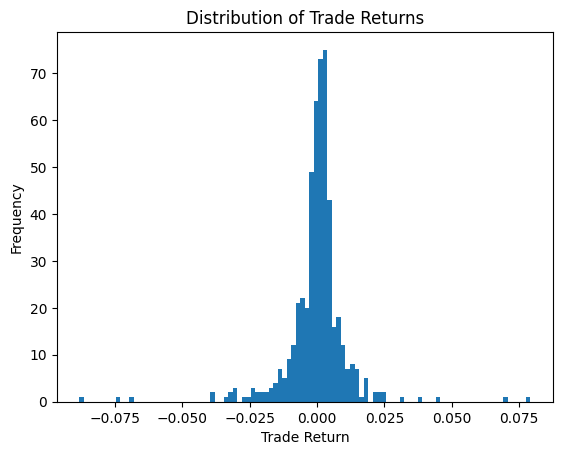

In [34]:

# MFI thresholds
mfi_buy_std = 20   # Buy threshold for MFI (oversold)
mfi_sell_std = 80  # Sell threshold for MFI (overbought)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []
trade_days = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    mfi = df['MFI'].iloc[i]
    
    # ENTRY: Only if not already holding a position
    if not holding_position and mfi < mfi_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):  # Out-of-bounds check
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and mfi > mfi_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):  # Out-of-bounds check
            break

        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")
        
        # Record trade
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        trade_days.append(exit_index - entry_index)
        
        holding_position = False

# --- Performance metrics ---
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

# Win rate
num_wins = sum(r > 0 for r in each_return)
winrate = num_wins / len(each_return) if each_return else 0

# Max drawdown
if each_return:
    equity_curve = np.cumprod([1 + r for r in each_return])
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()
else:
    max_drawdown = 0

# Average return per day (while in trade)
total_days = sum(trade_days) if trade_days else 0
average_return_per_day = (sum(each_return) / total_days) if total_days > 0 else 0

print("MFI (14-period window, Buy <20, Sell >80)")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4}")
print(f"Average return per day (while in trade): {average_return_per_day:.6f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max drawdown: {max_drawdown:.2%}")

print("\nSample trades:")
for i in range(min(10, len(each_return))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, "
          f"Days held: {trade_days[i]}, Each Return: {each_return[i]:.4%}")

plt.hist(each_return, bins=100)
plt.title("Distribution of Trade Returns")
plt.xlabel("Trade Return")
plt.ylabel("Frequency")
plt.show()


In [21]:
# RVI (using RSI crossover)
holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(1, len(df) - 1):
    rvi_prev = df['RVI'].iloc[i - 1]
    rsi_prev = df['RSI'].iloc[i - 1]
    rvi = df['RVI'].iloc[i]
    rsi = df['RSI'].iloc[i]
    
    # ENTRY: RVI crosses above RSI
    if not holding_position and (rvi_prev < rsi_prev) and (rvi > rsi):
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: RVI crosses below RSI
    elif holding_position and (rvi_prev > rsi_prev) and (rvi < rsi):
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)

        holding_position = False

# 
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("RVI/RSI Crossover Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4f}")

print("\nSample trades:")
for i in range(min(10, len(each_return))):
    print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")

print(f"Average return per trade: {np.mean(each_return):.6f}")


RVI/RSI Crossover Strategy
Number of trades: 0
Sum of return: 0.0000
Cumulative return: 0.0000%
Average return per trade: 0.0000

Sample trades:
Average return per trade: nan


D:\Anaconda\envs\notebook-7.3.2\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\Anaconda\envs\notebook-7.3.2\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [22]:
print("RVI/RSI Crossover Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
if len(each_return) > 0:
    print(f"Average return per trade: {average_return:.4f}")
else:
    print("Average return per trade: N/A (no trades executed)")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")
    print(f"Average return per trade: {np.mean(each_return):.6f}")
else:
    print("No sample trades: No trades executed.")


RVI/RSI Crossover Strategy
Number of trades: 0
Sum of return: 0.0000
Cumulative return: 0.0000%
Average return per trade: N/A (no trades executed)

Sample trades:
No sample trades: No trades executed.


Williams %R Strategy
Number of trades: 2514
Sum of return: 0.0638
Cumulative return: 3.1524%
Average return per trade: 0.0000
Average return per day (while in trade): 0.0000013582
Win rate: 65.23%
Max drawdown: -24.73%

Sample trades:
Trade 1: Entry at 1, Exit at 21, Days held: 20, Each Return: -0.4413%
Trade 2: Entry at 45, Exit at 87, Days held: 42, Each Return: -1.1193%
Trade 3: Entry at 107, Exit at 131, Days held: 24, Each Return: -0.6251%
Trade 4: Entry at 145, Exit at 147, Days held: 2, Each Return: 0.2654%
Trade 5: Entry at 152, Exit at 157, Days held: 5, Each Return: 0.3361%
Trade 6: Entry at 209, Exit at 226, Days held: 17, Each Return: 0.0393%
Trade 7: Entry at 320, Exit at 325, Days held: 5, Each Return: 0.6583%
Trade 8: Entry at 329, Exit at 359, Days held: 30, Each Return: -1.4876%
Trade 9: Entry at 381, Exit at 385, Days held: 4, Each Return: 0.8314%
Trade 10: Entry at 391, Exit at 414, Days held: 23, Each Return: -0.0881%


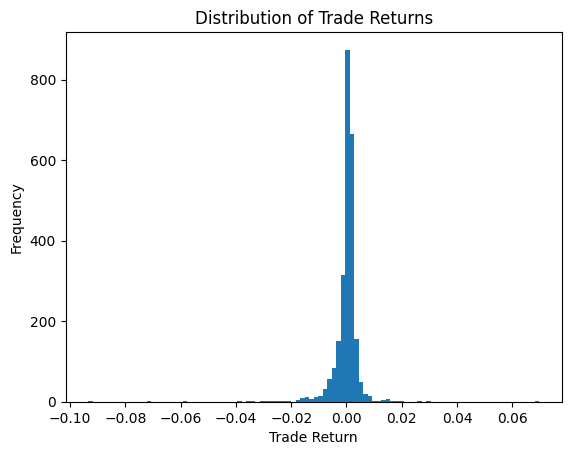

In [42]:
# Williams%
import numpy as np
import matplotlib.pyplot as plt

wpr_buy_std = -80    # Buy threshold for Williams %R (oversold)
wpr_sell_std = -20   # Sell threshold for Williams %R (overbought)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []
trade_days = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    wpr = df['WilliamsR'].iloc[i]   # Replace with your actual column name if different

    # ENTRY: Only if not already holding a position
    if not holding_position and wpr < wpr_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and wpr > wpr_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        trade_days.append(exit_index - entry_index)

        holding_position = False

# --- Performance metrics ---
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

# Win rate
num_wins = sum(r > 0 for r in each_return)
winrate = num_wins / len(each_return) if each_return else 0

# Max drawdown
if each_return:
    equity_curve = np.cumprod([1 + r for r in each_return])
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()
else:
    max_drawdown = 0

# Average return per day (while in trade)
total_days = sum(trade_days) if trade_days else 0
average_return_per_day = (sum(each_return) / total_days) if total_days > 0 else 0

print("Williams %R Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4f}" if len(each_return) > 0 else "Average return per trade: N/A (no trades executed)")
print(f"Average return per day (while in trade): {average_return_per_day:.10f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max drawdown: {max_drawdown:.2%}")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Days held: {trade_days[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")

plt.hist(each_return, bins=100)
plt.title("Distribution of Trade Returns")
plt.xlabel("Trade Return")
plt.ylabel("Frequency")
plt.show()


In [24]:
# PPO
ppo_buy_std = -10    # Buy threshold for PPO (oversold)
ppo_sell_std = 10    # Sell threshold for PPO (overbought)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    ppo = df['PPO'].iloc[i]   # Replace with your actual PPO column name if different

    # ENTRY: Only if not already holding a position
    if not holding_position and ppo < ppo_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and ppo > ppo_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)

        holding_position = False

#
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("PPO Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
if len(each_return) > 0:
    print(f"Average return per trade: {average_return:.4f}")
else:
    print("Average return per trade: N/A (no trades executed)")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")


PPO Strategy
Number of trades: 0
Sum of return: 0.0000
Cumulative return: 0.0000%
Average return per trade: N/A (no trades executed)

Sample trades:
No sample trades: No trades executed.


In [25]:
# Stocj L
stoch_buy_std = 20    # Buy threshold for Stochastic Oscillator (oversold)
stoch_sell_std = 80   # Sell threshold for Stochastic Oscillator (overbought)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    stoch = df['Stoch_K'].iloc[i]   # Replace with your actual column name if needed

    # ENTRY: Only if not already holding a position
    if not holding_position and stoch < stoch_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and stoch > stoch_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)

        holding_position = False

#
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("Stochastic Oscillator Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
if len(each_return) > 0:
    print(f"Average return per trade: {average_return:.4f}")
else:
    print("Average return per trade: N/A (no trades executed)")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")


Stochastic Oscillator Strategy
Number of trades: 2514
Sum of return: 0.0638
Cumulative return: 3.1524%
Average return per trade: 0.0000

Sample trades:
Trade 1: Entry at 1, Exit at 21, Each Return: -0.4413%
Trade 2: Entry at 45, Exit at 87, Each Return: -1.1193%
Trade 3: Entry at 107, Exit at 131, Each Return: -0.6251%
Trade 4: Entry at 145, Exit at 147, Each Return: 0.2654%
Trade 5: Entry at 152, Exit at 157, Each Return: 0.3361%
Trade 6: Entry at 209, Exit at 226, Each Return: 0.0393%
Trade 7: Entry at 320, Exit at 325, Each Return: 0.6583%
Trade 8: Entry at 329, Exit at 359, Each Return: -1.4876%
Trade 9: Entry at 381, Exit at 385, Each Return: 0.8314%
Trade 10: Entry at 391, Exit at 414, Each Return: -0.0881%


Stochastic Oscillator Strategy
Number of trades: 2514
Sum of return: 0.0638
Cumulative return: 3.1524%
Average return per trade: 0.0000
Average return per day (while in trade): 0.000001
Win rate: 65.23%
Max drawdown: -24.73%

Sample trades:
Trade 1: Entry at 1, Exit at 21, Days held: 20, Each Return: -0.4413%
Trade 2: Entry at 45, Exit at 87, Days held: 42, Each Return: -1.1193%
Trade 3: Entry at 107, Exit at 131, Days held: 24, Each Return: -0.6251%
Trade 4: Entry at 145, Exit at 147, Days held: 2, Each Return: 0.2654%
Trade 5: Entry at 152, Exit at 157, Days held: 5, Each Return: 0.3361%
Trade 6: Entry at 209, Exit at 226, Days held: 17, Each Return: 0.0393%
Trade 7: Entry at 320, Exit at 325, Days held: 5, Each Return: 0.6583%
Trade 8: Entry at 329, Exit at 359, Days held: 30, Each Return: -1.4876%
Trade 9: Entry at 381, Exit at 385, Days held: 4, Each Return: 0.8314%
Trade 10: Entry at 391, Exit at 414, Days held: 23, Each Return: -0.0881%


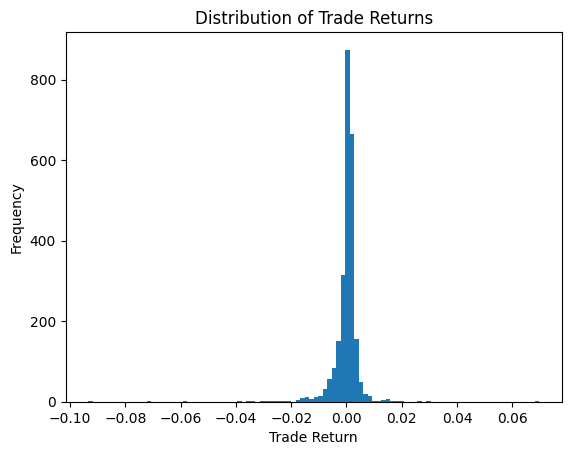

In [35]:
# Stoch, winrate, max drawdown
stoch_buy_std = 20    # Buy threshold for Stochastic Oscillator (oversold)
stoch_sell_std = 80   # Sell threshold for Stochastic Oscillator (overbought)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []
trade_days = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    stoch = df['Stoch_K'].iloc[i]   # Replace with your actual column name if needed

    # ENTRY: Only if not already holding a position
    if not holding_position and stoch < stoch_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and stoch > stoch_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        trade_days.append(exit_index - entry_index)

        holding_position = False

# --- Performance metrics ---
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

# Win rate
num_wins = sum(r > 0 for r in each_return)
winrate = num_wins / len(each_return) if each_return else 0

# Max drawdown
if each_return:
    equity_curve = np.cumprod([1 + r for r in each_return])
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()
else:
    max_drawdown = 0

# Average return per day (while in trade)
total_days = sum(trade_days) if trade_days else 0
average_return_per_day = (sum(each_return) / total_days) if total_days > 0 else 0

print("Stochastic Oscillator Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4f}" if len(each_return) > 0 else "Average return per trade: N/A (no trades executed)")
print(f"Average return per day (while in trade): {average_return_per_day:.6f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max drawdown: {max_drawdown:.2%}")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Days held: {trade_days[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")

plt.hist(each_return, bins=100)
plt.title("Distribution of Trade Returns")
plt.xlabel("Trade Return")
plt.ylabel("Frequency")
plt.show()


In [26]:
# IBS
ibs_buy_std = 0.2   # Buy threshold for IBS (oversold)
ibs_sell_std = 0.9  # Sell threshold for IBS (overbought)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    ibs = df['IBS'].iloc[i]   # Replace with your IBS column name if different

    # ENTRY: Only if not already holding a position
    if not holding_position and ibs < ibs_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and ibs > ibs_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)

        holding_position = False

#
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("IBS Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
if len(each_return) > 0:
    print(f"Average return per trade: {average_return:.4f}")
else:
    print("Average return per trade: N/A (no trades executed)")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")


IBS Strategy
Number of trades: 8421
Sum of return: 0.0467
Cumulative return: 0.7886%
Average return per trade: 0.0000

Sample trades:
Trade 1: Entry at 1, Exit at 5, Each Return: -0.0913%
Trade 2: Entry at 6, Exit at 32, Each Return: -0.0689%
Trade 3: Entry at 38, Exit at 48, Each Return: -0.3473%
Trade 4: Entry at 56, Exit at 72, Each Return: -0.6132%
Trade 5: Entry at 74, Exit at 75, Each Return: 0.1765%
Trade 6: Entry at 80, Exit at 94, Each Return: 0.3885%
Trade 7: Entry at 100, Exit at 104, Each Return: -0.0336%
Trade 8: Entry at 105, Exit at 106, Each Return: 0.0841%
Trade 9: Entry at 107, Exit at 130, Each Return: -0.6952%
Trade 10: Entry at 134, Exit at 154, Each Return: -0.0056%


In [27]:
# CMF
cmf_buy_std = -0.25   # More conservative: use -0.20 if you prefer
cmf_sell_std = 0.25   # More conservative: use 0.20 if you prefer

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    cmf = df['CMF'].iloc[i]   # Replace with your CMF column name if different

    # ENTRY: Only if not already holding a position
    if not holding_position and cmf < cmf_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and cmf > cmf_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        # Debug
        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)

        holding_position = False

#
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

print("CMF Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
if len(each_return) > 0:
    print(f"Average return per trade: {average_return:.4f}")
else:
    print("Average return per trade: N/A (no trades executed)")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")


CMF Strategy
Number of trades: 434
Sum of return: 0.1580
Cumulative return: 13.9496%
Average return per trade: 0.0004

Sample trades:
Trade 1: Entry at 7, Exit at 32, Each Return: 0.2699%
Trade 2: Entry at 57, Exit at 94, Each Return: -0.2927%
Trade 3: Entry at 117, Exit at 162, Each Return: 0.4742%
Trade 4: Entry at 335, Exit at 371, Each Return: 0.1894%
Trade 5: Entry at 637, Exit at 668, Each Return: -0.0108%
Trade 6: Entry at 847, Exit at 937, Each Return: 0.0054%
Trade 7: Entry at 957, Exit at 976, Each Return: 0.2650%
Trade 8: Entry at 1051, Exit at 1139, Each Return: -0.0805%
Trade 9: Entry at 1274, Exit at 1431, Each Return: 0.2176%
Trade 10: Entry at 1652, Exit at 1671, Each Return: 0.3854%


CMF Strategy
Number of trades: 434
Sum of return: 0.1580
Cumulative return: 13.9496%
Average return per trade: 0.0004
Average return per day (while in trade): 0.0000038131
Win rate: 61.75%
Max drawdown: -26.10%

Sample trades:
Trade 1: Entry at 7, Exit at 32, Days held: 25, Each Return: 0.2699%
Trade 2: Entry at 57, Exit at 94, Days held: 37, Each Return: -0.2927%
Trade 3: Entry at 117, Exit at 162, Days held: 45, Each Return: 0.4742%
Trade 4: Entry at 335, Exit at 371, Days held: 36, Each Return: 0.1894%
Trade 5: Entry at 637, Exit at 668, Days held: 31, Each Return: -0.0108%
Trade 6: Entry at 847, Exit at 937, Days held: 90, Each Return: 0.0054%
Trade 7: Entry at 957, Exit at 976, Days held: 19, Each Return: 0.2650%
Trade 8: Entry at 1051, Exit at 1139, Days held: 88, Each Return: -0.0805%
Trade 9: Entry at 1274, Exit at 1431, Days held: 157, Each Return: 0.2176%
Trade 10: Entry at 1652, Exit at 1671, Days held: 19, Each Return: 0.3854%


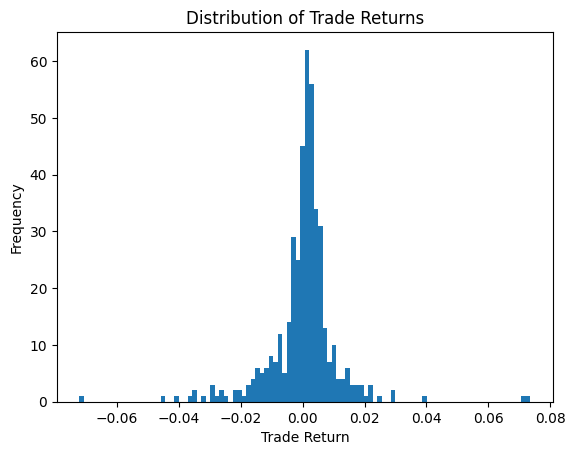

In [40]:
import numpy as np
import matplotlib.pyplot as plt

cmf_buy_std = -0.25   # Buy threshold for CMF (more conservative: use -0.20 if you prefer)
cmf_sell_std = 0.25   # Sell threshold for CMF (more conservative: use 0.20 if you prefer)

holding_position = False
entry_index = None

buy_indices = []
sell_indices = []
each_return = []
trade_days = []

# --- Main trading loop ---
for i in range(len(df) - 1):
    cmf = df['CMF'].iloc[i]   # Replace with your CMF column name if different

    # ENTRY: Only if not already holding a position
    if not holding_position and cmf < cmf_buy_std:
        entry_index = i + 1  # Buy at NEXT bar's Open
        if entry_index >= len(df):
            break
        holding_position = True

    # EXIT: Only if holding a position
    elif holding_position and cmf > cmf_sell_std:
        exit_index = i + 1  # Sell at NEXT bar's Open
        if exit_index >= len(df):
            break

        if entry_index == exit_index:
            print(f"Warning: Buy and Sell at the same bar {entry_index}")

        # ---- Record trade info ----
        buy_indices.append(entry_index)
        sell_indices.append(exit_index)
        buy_price = df['Open'].iloc[entry_index]
        sell_price = df['Open'].iloc[exit_index]
        trade_return = (sell_price - buy_price) / buy_price
        each_return.append(trade_return)
        trade_days.append(exit_index - entry_index)

        holding_position = False

# --- Performance metrics ---
sum_return = sum(each_return)
cumulative_return = (np.prod([1 + r for r in each_return]) - 1) if each_return else 0
average_return = sum(each_return) / len(each_return) if each_return else 0

# Win rate
num_wins = sum(r > 0 for r in each_return)
winrate = num_wins / len(each_return) if each_return else 0

# Max drawdown
if each_return:
    equity_curve = np.cumprod([1 + r for r in each_return])
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()
else:
    max_drawdown = 0

# Average return per day (while in trade)
total_days = sum(trade_days) if trade_days else 0
average_return_per_day = (sum(each_return) / total_days) if total_days > 0 else 0

print("CMF Strategy")
print(f"Number of trades: {len(each_return)}")
print(f"Sum of return: {sum_return:.4f}")
print(f"Cumulative return: {cumulative_return:.4%}")
print(f"Average return per trade: {average_return:.4f}" if len(each_return) > 0 else "Average return per trade: N/A (no trades executed)")
print(f"Average return per day (while in trade): {average_return_per_day:.10f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max drawdown: {max_drawdown:.2%}")

print("\nSample trades:")
if len(each_return) > 0:
    for i in range(min(10, len(each_return))):
        print(f"Trade {i+1}: Entry at {buy_indices[i]}, Exit at {sell_indices[i]}, Days held: {trade_days[i]}, Each Return: {each_return[i]:.4%}")
else:
    print("No sample trades: No trades executed.")

plt.hist(each_return, bins=100)
plt.title("Distribution of Trade Returns")
plt.xlabel("Trade Return")
plt.ylabel("Frequency")
plt.show()
